In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, Flatten,
    Dense, Dropout, BatchNormalization, Concatenate, Embedding
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

In [2]:
# Carga solo las columnas que necesites para ahorrar memoria
df_parquet = pd.read_parquet('../../../MPtrj-2022.9_full.parquet', engine='pyarrow')

# Visualiza las primeras filas para entender la jerarquía
print(df_parquet.head())

   nsites     elements  nelements                       composition  \
0       5  [C, In, Yb]          3  [(Yb, 3.0), (In, 1.0), (C, 1.0)]   
1       5  [C, In, Yb]          3  [(C, 1.0), (In, 1.0), (Yb, 3.0)]   
2       5  [C, In, Yb]          3  [(C, 1.0), (In, 1.0), (Yb, 3.0)]   
3       5  [C, In, Yb]          3  [(Yb, 3.0), (In, 1.0), (C, 1.0)]   
4      20      [O, Pb]          2            [(Pb, 8.0), (O, 12.0)]   

                composition_reduced formula_pretty formula_anonymous  chemsys  \
0  [(Yb, 3.0), (In, 1.0), (C, 1.0)]         Yb3InC              ABC3  C-In-Yb   
1  [(C, 1.0), (In, 1.0), (Yb, 3.0)]         Yb3InC              ABC3  C-In-Yb   
2  [(C, 1.0), (In, 1.0), (Yb, 3.0)]         Yb3InC              ABC3  C-In-Yb   
3  [(Yb, 3.0), (In, 1.0), (C, 1.0)]         Yb3InC              ABC3  C-In-Yb   
4             [(Pb, 2.0), (O, 3.0)]          Pb2O3              A2B3     O-Pb   

       volume   density  ...  \
0  129.803781  8.263419  ...   
1  129.007019  8.31445

In [3]:
print(df_parquet.dtypes)

nsites                                  int64
elements                               object
nelements                               int64
composition                            object
composition_reduced                    object
formula_pretty                         object
formula_anonymous                      object
chemsys                                object
volume                                float64
density                               float64
density_atomic                        float64
symmetry                               object
cell                                   object
atomic_numbers                         object
cart_coords                            object
magmoms                                object
energy                                float64
forces                                 object
abs_forces                             object
stress                                 object
stress_matrix                          object
bandgap                           

In [ ]:
# filtrar filas válidas
df_parquet = df_parquet[df_parquet["provenance"].notna()]

# extraer campos
df_parquet["task_id"] = df_parquet["provenance"].apply(lambda x: x.get("task_id"))
df_parquet["calcs_reversed_index"] = df_parquet["provenance"].apply(lambda x: x.get("calcs_reversed_index"))
df_parquet["ionic_step_index"] = df_parquet["provenance"].apply(lambda x: x.get("ionic_step_index"))

# 1. quedarse con cálculo final
min_calc = df_parquet.groupby("task_id")["calcs_reversed_index"].transform("min")
df_last_calc = df_parquet[df_parquet["calcs_reversed_index"] == min_calc].copy()

# 2. quedarse con último paso iónico
max_step = df_last_calc.groupby("task_id")["ionic_step_index"].transform("max")
df_relaxed = df_last_calc[df_last_calc["ionic_step_index"] == max_step].copy()

df_relaxed = df_relaxed.dropna(subset=["energy", "bandgap", "cohesive_energy_per_atom", "corrected_cohesive_energy_per_atom"]).reset_index(drop=True)

In [5]:
print(df_relaxed[["energy", "bandgap", "cohesive_energy_per_atom", "corrected_cohesive_energy_per_atom"]].isnull().sum())
print(len(df_relaxed))

energy                                0
bandgap                               0
cohesive_energy_per_atom              0
corrected_cohesive_energy_per_atom    0
dtype: int64
291023


In [6]:
df = df_relaxed.sample(100000, random_state=33).reset_index(drop=True).drop(columns=[
    "nelements",
    "composition_reduced",
    "formula_pretty",
    "formula_anonymous",
    "chemsys",
    "atomic_numbers",
    "magmoms",
    "forces",
    "abs_forces",
    "stress",
    "stress_matrix",
    "functional",
    "bader_charges",
    "bader_magmoms",
    "provenance",
    "task_id",
    "calcs_reversed_index",
    "ionic_step_index"
])

In [7]:
del df_parquet
del df_last_calc
del min_calc
del max_step
del df_relaxed

In [ ]:
# Extracción de características de simetría cristalina
# Convertir sistema cristalino (string) en one-hot encoding para redes neuronales
# Crear columna numérica del número de grupo espacial (0-229)

df["crystal_system"] = df["symmetry"].apply(lambda x: x["crystal_system"])

# One-hot encoding de sistemas cristalinos (Cúbico, Hexagonal, etc.)
symmetry_features = pd.get_dummies(
df["crystal_system"],
prefix="sym"
)
df = pd.concat([df, symmetry_features], axis=1)

# Extraer número de grupo espacial (0-229) como feature para embedding
df["sym_num"] = df["symmetry"].apply(lambda x: x["number"] - 1)

# Eliminar columna original de simetría (ya fue procesada)
df = df.drop(columns=["symmetry", "crystal_system"])

In [ ]:
from mendeleev import element

# Tabla de características de elementos: 8 propiedades fisicoquímicas por elemento
element_features = {}

for Z in range(1, 119):
    el = element(Z)

    # Extraer 8 propiedades del elemento (Z=1 a 118)
    valores = [
        el.atomic_number,  # Número atómico
        el.atomic_weight,  # Peso atómico
        el.en_pauling,  # Electronegatividad
        el.atomic_radius,  # Radio atómico
        el.covalent_radius,  # Radio covalente
        el.nvalence(),  # Electrones de valencia
        el.electron_affinity,  # Afinidad electrónica
        el.ionenergies.get(1, None)  # Energía de ionización
    ]

    # sustituir None por 0
    valores = [0 if v is None else v for v in valores]

    element_features[el.symbol] = valores

# convertir valores a matriz
elements = list(element_features.keys())
values = np.array(list(element_features.values()), dtype=float)

# calcular min y max por columna
mins = values.min(axis=0)
maxs = values.max(axis=0)

# normalizar: (x - min) / (max - min) -> rango [0, 1] para todas las propiedades
normalized = (values - mins) / (maxs - mins)

# reconstruir diccionario
tabla = {
    el: normalized[i].tolist()
    for i, el in enumerate(elements)
}
# Mostrar la tabla normalizada
print(tabla)

{'H': [0.0, 0.0, 0.5527638190954774, 0.09615384615384616, 0.0, 0.0, 0.8773832745850173, 0.5530654187648099], 'He': [0.008547008547008548, 0.010220763706858892, 0.0, 0.46153846153846156, 0.07, 0.0625, 0.0, 1.0], 'Li': [0.017094017094017096, 0.020246286588029707, 0.24623115577889446, 0.5576923076923077, 0.5050000000000001, 0.0, 0.8715432880540562, 0.21928782245190143], 'Be': [0.02564102564102564, 0.027318776963193528, 0.39447236180904527, 0.40384615384615385, 0.35000000000000003, 0.0625, 0.7420839906102783, 0.3791658803555423], 'B': [0.03418803418803419, 0.03345483835736129, 0.5125628140703518, 0.3269230769230769, 0.265, 0.125, 0.8570307846894775, 0.3374908574589844], 'C': [0.042735042735042736, 0.03755392638706859, 0.6407035175879396, 0.2692307692307692, 0.21500000000000002, 0.1875, 0.8991706889692216, 0.4579700591617243], 'N': [0.05128205128205128, 0.0443663990825688, 0.7638190954773869, 0.25, 0.19500000000000003, 0.25, 0.7849790189692539, 0.59112132620091], 'O': [0.05982905982905983, 

In [10]:
def procesar_muestra(sample):
    """
    Extrae y procesa las coordenadas cartesianas de estructuras cristalinas.
    
    Para cada muestra (estructura cristalina), convierte los datos de composición
    (elementos y cantidades) en listas de tuplas con coordenadas (x, y, z) y símbolo del elemento.
    
    Args:
        sample (DataFrame): DataFrame con columnas 'composition' y 'cart_coords'
                           - composition: lista de [símbolo, cantidad] para cada elemento
                           - cart_coords: lista de [x, y, z] para cada átomo en la estructura
    
    Returns:
        samplist (list): Lista de listas donde cada elemento es:
                        [(x1, y1, z1, elem1), (x2, y2, z2, elem2), ...]
                        para cada muestra
    """
    samplist = []

    # Iterar sobre cada fila (muestra/estructura) del DataFrame
    for _, row in sample.iterrows():
        # Extraer información de composición (elementos y sus cantidades)
        comp = row['composition']
        n = 0  # Índice actual en cart_coords
        lista = []
        
        # Para cada elemento en la composición
        for element in comp:
            # m = índice final del rango de átomos para este elemento
            m = n + int(element[1])
            
            # Extraer coordenadas de todos los átomos de este elemento
            for coord in row['cart_coords'][n:m]:
                # Crear tupla: (x, y, z, símbolo_elemento)
                tuple_coord = (float(coord[0]), float(coord[1]), float(coord[2]), element[0])
                lista.append(tuple_coord)
            
            # Actualizar índice para el próximo elemento
            n = m
        
        samplist.append(lista)

    return samplist


In [11]:
def calculo_unidad(muestra, length):
    """
    Calcula el factor de escala para discretizar una estructura 3D en una imagen 2D.
    
    Determina la distancia máxima en cualquier eje (x, y, z) y divide entre el tamaño
    de la imagen para obtener cuánta distancia física corresponde a 1 píxel.
    
    Args:
        muestra (list): Lista de tuplas (x, y, z, elemento)
        length (int): Tamaño deseado de la imagen en píxeles (length x length)
    
    Returns:
        float: Distancia en unidades de la estructura que corresponde a 1 píxel.
               Si es 0, significa que la estructura es muy pequeña (< 2 átomos).
    """
    envergadura = 0  # Rango máximo encontrado en las 3 dimensiones
    
    # Para cada dimensión del espacio (x=0, y=1, z=2)
    for i in range(3):
        # Inicializar min y max al primer valor de coordenada en esta dimensión
        min_val = muestra[0][i]
        max_val = muestra[0][i]
        
        # Encontrar mínimo y máximo para esta dimensión
        for element in muestra:
            coord = element[i]
            if coord < min_val:
                min_val = coord
            if coord > max_val:
                max_val = coord
        
        # Calcular amplitud (rango) y actualizar el máximo global si es mayor
        amplitud = max_val - min_val
        if amplitud > envergadura:
            envergadura = amplitud
    
    # Calcular unidad: distancia física por píxel
    # Esto normaliza cualquier estructura al tamaño de la imagen
    unidad = envergadura / (length - 1)

    return unidad


In [12]:
def imagen(muestra, unidad, length, normal, sentido=1):
    """
    Genera una proyección 2D de una estructura 3D con encoding de características químicas.
    
    Crea una imagen donde cada píxel contiene un vector de 8 características fisicoquímicas
    del elemento en esa posición. La proyección se realiza perpendicular al eje 'normal'.
    
    Args:
        muestra (list): Lista de tuplas (x, y, z, símbolo_elemento)
        unidad (float): Factor de escala (distancia física por píxel)
        length (int): Tamaño de la imagen (length x length píxeles)
        normal (int): Eje perpendicular a la proyección (0=X, 1=Y, 2=Z)
        sentido (int): Dirección de lectura (1=positivo, -1=negativo). Permite capturar simetría.
    
    Returns:
        np.ndarray: Array de forma (length, length, 8) con características de elementos.
                   Cada píxel contiene 8 valores que codifican propiedades del elemento.
    """
    # Inicializar imagen vacía: length x length píxeles, 8 canales (características por elemento)
    imagen = np.zeros((length, length, 8))
    
    # Caso especial: estructura muy pequeña (< 2 átomos y rango ~0)
    # Distribuir elemento en las 4 esquinas para que sea visible
    if unidad == 0 and len(muestra) < 2:
        imagen[0, 0] = tabla[muestra[0][3]]
        imagen[0, length - 1] = tabla[muestra[0][3]]
        imagen[length - 1, 0] = tabla[muestra[0][3]]
        imagen[length - 1, length - 1] = tabla[muestra[0][3]]
    else:
        # ========== NORMALIZAR COORDENADAS ==========
        # Encontrar valores mínimos para cada dimensión
        minimos = [0, 0, 0]
        auxlist = []
        
        for i in range(3):
            min_val = muestra[0][i]
            for element in muestra:
                coord = element[i]
                if coord < min_val:
                    min_val = coord
                minimos[i] = min_val
        
        # Trasladar todas las coordenadas al origen (restar mínimo)
        for element in muestra:
            auxlist.append([
                element[0] - minimos[0],
                element[1] - minimos[1],
                element[2] - minimos[2],
                element[3]  # símbolo del elemento
            ])
        
        # ========== ORDENAR POR PROFUNDIDAD ==========
        # Ordenar por el eje normal para procesar de atrás hacia adelante
        auxlist.sort(key=lambda x: x[normal])
        
        # ========== CONVERTIR A PÍXELES ==========
        # Convertir coordenadas normalizadas a índices de píxeles
        for i in range(len(auxlist)):
            element = auxlist[i]
            # Dividir por 'unidad' para obtener posición en píxeles
            auxlist[i][:3] = [round(coord / unidad) for coord in element[:3]]
        
        # ========== PROYECTAR EN 2D ==========
        # Determinar los dos ejes a proyectar (excluyendo el normal)
        ejes = [0, 1, 2]
        ejes.remove(normal)
        
        # Llenar imagen: para cada elemento, poner sus características en el píxel correspondiente
        for element in auxlist[::sentido]:  # Iterar en orden normal o inverso según 'sentido'
            coord = element[0:3]
            # Mapear coordenadas 3D a píxeles 2D
            # ejes[0] - normal: ajusta índice de fila
            # sentido*ejes[1] - normal + ((sentido-1)//2): ajusta índice de columna con dirección
            imagen[
                coord[ejes[-normal]],
                sentido * coord[ejes[1 - normal] ] + ((sentido - 1) // 2)
            ] = tabla[element[3]]

    return imagen


In [13]:
def crear_imagenes(sample, length=10):
    """
    Crea representaciones visuales multivista de estructuras cristalinas 3D.
    
    Para cada estructura, genera 6 proyecciones 2D diferentes:
    - 3 planos ortogonales (XY, YZ, ZX)
    - 2 direcciones de lectura para cada plano (+, -)
    
    Las imágenes se concatenan en una matriz 2x3 para capturar información 3D completa.
    
    Args:
        sample (DataFrame): Muestras de estructuras con composición y coordenadas
        length (int): Tamaño de cada imagen individual (píxeles). Default=10
    
    Returns:
        list: Lista de arrays de forma (2*length, 3*length, 8)
              Cada array representa una estructura proyectada en 6 vistas.
    """
    imagenes = []
    
    # Procesar composición y coordenadas de todas las muestras
    samplist = procesar_muestra(sample)
    
    # Para cada muestra (estructura)
    for muestra in samplist:
        # Calcular factor de escala para normalizar esta estructura específica
        unidad = calculo_unidad(muestra, length)
        
        # ========== PRIMERA FILA: SENTIDO POSITIVO ==========
        # Generar 3 proyecciones principales en dirección positiva
        xy1 = imagen(muestra, unidad, length, normal=2, sentido=1)   # Proyección XY, vista desde Z+
        yz1 = imagen(muestra, unidad, length, normal=0, sentido=1)   # Proyección YZ, vista desde X+
        zx1 = imagen(muestra, unidad, length, normal=1, sentido=1)   # Proyección ZX, vista desde Y+
        
        # ========== SEGUNDA FILA: SENTIDO INVERSO ==========
        # Generar 3 proyecciones en dirección inversa (para capturar simetría/perspectiva inversa)
        xy2 = imagen(muestra, unidad, length, normal=2, sentido=-1)  # Proyección XY desde Z-
        yz2 = imagen(muestra, unidad, length, normal=0, sentido=-1)  # Proyección YZ desde X-
        zx2 = imagen(muestra, unidad, length, normal=1, sentido=-1)  # Proyección ZX desde Y-
        
        # ========== CONCATENACIÓN: 2x3 GRID ==========
        # Primera fila: concatenar las 3 proyecciones horizontalmente
        imagen1 = np.concatenate((xy1, yz1, zx1), axis=1)  # Forma: (length, 3*length, 8)
        
        # Segunda fila: concatenar las 3 proyecciones inversa (horizontalmente)
        imagen2 = np.concatenate((xy2, yz2, zx2), axis=1)  # Forma: (length, 3*length, 8)
        
        # Imagen final: concatenar filas verticalmente
        imagen_total = np.concatenate((imagen1, imagen2), axis=0)  # Forma: (2*length, 3*length, 8)
        
        imagenes.append(imagen_total)
    
    return imagenes


In [ ]:
def Deep_learning(tabular, imagenes, y, seed, grafica):
    """
    Modelo híbrido CNN + Tabular para regresión multisalida.
    Predice simultáneamente:
        - energy
        - bandgap
        - cohesive_energy_per_atom
        - corrected_cohesive_energy_per_atom

    Args:
        tabular (DataFrame): Variables tabulares de entrada.
        imagenes (list o array): Imágenes multicanal.
        y (array o DataFrame): Targets con forma (N, 4).
        seed (int): Semilla para reproducibilidad.
        grafica (bool): Mostrar resumen y curvas de entrenamiento.

    Returns:
        dict: Métricas por target y medias globales.
    """

    # ==========================
    # PREPARACIÓN DE DATOS
    # ==========================
    X_img = np.array(imagenes)
    X_tab = np.array(tabular.drop(columns=["sym_num"]))
    y = np.array(y)   # ahora debe tener forma (N, 4)

    target_names = [
        "energy",
        "bandgap",
        "cohesive_energy_per_atom",
        "corrected_cohesive_energy_per_atom"
    ]

    # Split train/test
    X_img_train, X_img_test, X_tab_train, X_tab_test, y_train, y_test = train_test_split(
        X_img, X_tab, y, test_size=0.2, random_state=seed
    )

    # Split train/val
    X_img_train, X_img_val, X_tab_train, X_tab_val, y_train, y_val = train_test_split(
        X_img_train, X_tab_train, y_train, test_size=0.2, random_state=seed
    )

    # ==========================
    # ESCALADO
    # ==========================
    # Escalado de variables tabulares
    scaler_X = MinMaxScaler()
    X_tab_train = scaler_X.fit_transform(X_tab_train)
    X_tab_val = scaler_X.transform(X_tab_val)
    X_tab_test = scaler_X.transform(X_tab_test)

    # Escalado de targets (muy recomendable en multisalida)
    scaler_y = StandardScaler()
    y_train_scaled = scaler_y.fit_transform(y_train)
    y_val_scaled = scaler_y.transform(y_val)

    # ==========================
    # ARQUITECTURA DEL MODELO
    # ==========================

    # -------- RAMA CNN --------
    input_img = Input(shape=X_img_train.shape[1:], name="input_imagen")

    x = Conv2D(32, (3, 3), activation="relu", padding="same")(input_img)
    x = MaxPooling2D((2, 2))(x)
    x = BatchNormalization()(x)

    x = Conv2D(64, (3, 3), activation="relu", padding="same")(x)
    x = MaxPooling2D((2, 2))(x)
    x = BatchNormalization()(x)

    x = Flatten()(x)
    x = Dense(128, activation="relu")(x)
    x = Dropout(0.4)(x)

    # -------- RAMA TABULAR --------
    input_tab = Input(shape=(X_tab_train.shape[1],), name="input_tabular")

    t = Dense(128, activation="relu")(input_tab)
    t = BatchNormalization()(t)
    t = Dropout(0.4)(t)
    t = Dense(128, activation="relu")(t)

    # -------- FUSIÓN --------
    combined = Concatenate()([x, t])

    z = Dense(128, activation="relu")(combined)
    z = Dropout(0.3)(z)
    z = Dense(64, activation="relu")(z)

    # Salida multisalida LINEAL
    output = Dense(4, activation="linear", name="output")(z)

    model = Model(inputs=[input_img, input_tab], outputs=output)

    # ==========================
    # COMPILACIÓN
    # ==========================
    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss="mse",
        metrics=["mae"]
    )

    if grafica:
        model.summary()

    # ==========================
    # CALLBACKS
    # ==========================
    callbacks = [
        EarlyStopping(
            monitor="val_loss",
            patience=10,
            restore_best_weights=True
        ),
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=5,
            min_lr=1e-6
        )
    ]

    # ==========================
    # ENTRENAMIENTO
    # ==========================
    history = model.fit(
        [X_img_train, X_tab_train],
        y_train_scaled,
        validation_data=([X_img_val, X_tab_val], y_val_scaled),
        epochs=100,
        batch_size=32,
        callbacks=callbacks,
        verbose=int(grafica)
    )

    # ==========================
    # PREDICCIÓN
    # ==========================
    y_pred_scaled = model.predict([X_img_test, X_tab_test], verbose=0)

    # Desescalar predicciones y targets
    y_pred = scaler_y.inverse_transform(y_pred_scaled)

    # ==========================
    # MÉTRICAS POR TARGET
    # ==========================
    mae = mean_absolute_error(y_test, y_pred, multioutput="raw_values")
    rmse = np.sqrt(mean_squared_error(y_test, y_pred, multioutput="raw_values"))
    r2 = r2_score(y_test, y_pred, multioutput="raw_values")

    # MAPE: se calcula, pero ojo con targets negativos o cercanos a 0
    mape = mean_absolute_percentage_error(y_test, y_pred, multioutput="raw_values")

    resultados = {
        target_names[i]: {
            "mae": float(mae[i]),
            "rmse": float(rmse[i]),
            "mape": float(mape[i]),
            "r2": float(r2[i])
        }
        for i in range(4)
    }

    # ==========================
    # VISUALIZACIÓN, Realizado por chatGPT
    # ==========================
    if grafica:
        plt.figure(figsize=(10, 4))

        plt.subplot(1, 2, 1)
        plt.plot(history.history["loss"], label="train", linewidth=2)
        plt.plot(history.history["val_loss"], label="val", linewidth=2)
        plt.title("Loss (MSE)")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.legend()
        plt.grid(alpha=0.3)

        plt.subplot(1, 2, 2)
        plt.plot(history.history["mae"], label="train", linewidth=2)
        plt.plot(history.history["val_mae"], label="val", linewidth=2)
        plt.title("MAE medio")
        plt.xlabel("Epoch")
        plt.ylabel("MAE")
        plt.legend()
        plt.grid(alpha=0.3)

        plt.tight_layout()
        plt.show()

    return resultados

In [ ]:
def Deep_learning_2(tabular, imagenes, y, seed, grafica):
    """
    Modelo completo: CNN + Tabular + Embedding de Simetría Cristalina.
    
    Arquitectura de fusión multimodal que integra tres tipos de información:
    1. Imágenes (CNN): Características visuales estructurales
    2. Propiedades (Tabular): Volumen, densidad, parámetros de celda
    3. Simetría (Embedding): Grupo espacial codificado en vector denso
    
    Esta es la arquitectura más completa, que combina todas las fuentes de información
    disponibles para la predicción de energía.
    
    Args:
        tabular (DataFrame): Propiedades + número de grupo espacial (sym_num)
        imagenes (list): Representaciones visuales multivista
        y (array): Energía (variable target)
        seed (int): Semilla para reproducibilidad
        grafica (bool): Mostrar gráficas y resumen
    
    Returns:
        tuple: (mae, rmse, mape, r2) - Métricas de evaluación
    """
    
    # ========== PREPARACIÓN DE DATOS ==========
    # Extraer número de grupo espacial para embedding
    X_sym = tabular["sym_num"].values.astype(int)
    
    # Convertir imágenes y propiedades a arrays
    X_img = np.array(imagenes)
    X_tab = np.array(tabular.drop(columns=["sym_num"]))
    y = np.array(y)

    # ========== SPLIT: SEPARACIÓN EN TRAIN/VAL/TEST ==========
    # Split 1: Separación de test (80% train, 20% test)
    X_img_train, X_img_test, X_tab_train, X_tab_test, X_sym_train, X_sym_test, y_train, y_test = train_test_split(
        X_img, X_tab, X_sym, y, test_size=0.2, random_state=seed
    )

    # Split 2: Separación de validación (80% de train, 20% val)
    X_img_train, X_img_val, X_tab_train, X_tab_val, X_sym_train, X_sym_val, y_train, y_val = train_test_split(
        X_img_train, X_tab_train, X_sym_train, y_train, test_size=0.2, random_state=seed
    )

    # ========== ESCALADO: NORMALIZAR PROPIEDADES TABULARES ==========
    scaler = MinMaxScaler()
    X_tab_train = scaler.fit_transform(X_tab_train)  # Aprender parámetros
    X_tab_val = scaler.transform(X_tab_val)  # Aplicar
    X_tab_test = scaler.transform(X_tab_test)  # Aplicar

    # Reshape para embedding (requiere 2D)
    X_sym_train = X_sym_train.reshape(-1, 1)
    X_sym_val = X_sym_val.reshape(-1, 1)
    X_sym_test = X_sym_test.reshape(-1, 1)

    # ========== ESCALADO: NORMALIZAR TARGETS ==========
    # Escalado de targets (muy recomendable en multisalida)
    scaler_y = StandardScaler()
    y_train_scaled = scaler_y.fit_transform(y_train)
    y_val_scaled = scaler_y.transform(y_val)

    # ========== CONSTRUCCIÓN DEL MODELO ==========
    
    # -------- RAMA 1: CNN (Procesamiento de Imágenes) --------
    input_img = Input(shape=X_img_train.shape[1:], name="input_imagen")

    # Bloque convolucional 1: detecta patrones pequeños
    x = Conv2D(32, (3, 3), activation="relu", padding="same")(input_img)
    x = MaxPooling2D((2, 2))(x)  # Reduce tamaño (3x más rápido)
    x = BatchNormalization()(x)  # Estabiliza entrenamiento

    # Bloque convolucional 2: detecta patrones complejos
    x = Conv2D(64, (3, 3), activation="relu", padding="same")(x)
    x = MaxPooling2D((2, 2))(x)  # Reduce tamaño nuevamente
    x = BatchNormalization()(x)

    # Síntesis final del bloque CNN
    x = Flatten()(x)  # Vectoriza características
    x = Dense(128, activation="relu")(x)  # Procesa
    x = Dropout(0.4)(x)  # Regularización

    # -------- RAMA 2: Propiedades Tabulares (Red Densa) --------
    input_tab = Input(shape=(X_tab_train.shape[1],), name="input_tabular")

    # Primera capa: procesar features básicas
    t = Dense(128, activation="relu")(input_tab)
    t = BatchNormalization()(t)  # Normalización
    t = Dropout(0.4)(t)  # Regularización

    # Segunda capa: síntesis de features
    t = Dense(128, activation="relu")(t)

    # -------- RAMA 3: Embedding de Simetría Cristalina --------
    # Transforma número de grupo espacial (0-229) en vector denso aprendible
    input_sym = Input(shape=(1,), name="input_sym")

    # Embedding layer: 230 posibles grupos espaciales -> vector 8D
    # Aprende representaciones que capturan patrones de simetría
    sym_emb = Embedding(input_dim=230, output_dim=8)(input_sym)
    sym_emb = Flatten()(sym_emb)  # Vectorizar (8D)

    # -------- FUSIÓN DE LAS 3 RAMAS --------
    # Concatenar todas las representaciones: 128 (CNN) + 128 (Tab) + 8 (Emb) = 264 features
    combined = Concatenate()([x, t, sym_emb])

    # -------- CAPAS FINALES DE SÍNTESIS ==========
    # Procesar features combinadas
    z = Dense(128, activation="relu")(combined)  # Síntesis
    z = Dropout(0.3)(z)  # Regularización
    z = Dense(64, activation="relu")(z)  # Refinamiento

    # Output: predicción multisalida (4 targets continuos)
    output = Dense(4, activation="linear", name="output")(z)

    # ========== COMPILACIÓN DEL MODELO ==========
    model = Model(inputs=[input_img, input_tab, input_sym], outputs=output)

    # Configurar proceso de entrenamiento
    model.compile(
        optimizer=Adam(learning_rate=1e-3),  # Adam: gradientes adaptativos
        loss="mse",  # Pérdida: error cuadrático medio
        metrics=["mae"]  # Métrica: error absoluto medio
    )

    if grafica:
        model.summary()  # Mostrar architecture del modelo

    # ========== CALLBACKS: MONITOREO DEL ENTRENAMIENTO ==========
    callbacks = [
        # EarlyStopping: detener si val_loss no mejora
        EarlyStopping(
            monitor="val_loss",
            patience=10,  # Esperar 10 epochs
            restore_best_weights=True  # Usar mejor modelo
        ),
        # ReduceLROnPlateau: reducir learning rate si se estanca
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,  # x0.5 el learning rate
            patience=5,  # Después de 5 epochs sin mejora
            min_lr=1e-6  # No bajar de 1e-6
        )
    ]

    # ========== ENTRENAMIENTO ==========
    history = model.fit(
        [X_img_train, X_tab_train, X_sym_train],  # 3 inputs
        y_train_scaled,  # Target escalado
        validation_data=([X_img_val, X_tab_val, X_sym_val], y_val_scaled),  # Validación escalada
        epochs=100,  # Máximo 100 epochs
        batch_size=32,  # Samples por batch
        callbacks=callbacks,
        verbose=int(grafica)  # Mostrar barra de progreso
    )

    # ========== EVALUACIÓN EN TEST SET ==========
    y_pred_scaled = model.predict([X_img_test, X_tab_test, X_sym_test])

    # Desescalar predicciones y targets
    y_pred = scaler_y.inverse_transform(y_pred_scaled)

    target_names = [
        "energy",
        "bandgap",
        "cohesive_energy_per_atom",
        "corrected_cohesive_energy_per_atom"
    ]

    # Calcular métricas de evaluación
    mae = mean_absolute_error(y_test, y_pred, multioutput="raw_values")
    rmse = np.sqrt(mean_squared_error(y_test, y_pred, multioutput="raw_values"))
    mape = mean_absolute_percentage_error(y_test, y_pred, multioutput="raw_values")
    r2 = r2_score(y_test, y_pred, multioutput="raw_values")

    resultados = {
        target_names[i]: {
            "mae": float(mae[i]),
            "rmse": float(rmse[i]),
            "mape": float(mape[i]),
            "r2": float(r2[i])
        }
        for i in range(4)
    }


    # ========== VISUALIZACIÓN, Realizado por chatGPT ==========
    if grafica:
        plt.figure(figsize=(10, 4))

        # Gráfica 1: Loss (entrenamiento vs validación)
        plt.subplot(1, 2, 1)
        plt.plot(history.history["loss"], label="train", linewidth=2)
        plt.plot(history.history["val_loss"], label="val", linewidth=2)
        plt.title("Loss (MSE)")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.legend()
        plt.grid(alpha=0.3)

        # Gráfica 2: MAE (entrenamiento vs validación)
        plt.subplot(1, 2, 2)
        plt.plot(history.history["mae"], label="train", linewidth=2)
        plt.plot(history.history["val_mae"], label="val", linewidth=2)
        plt.title("MAE")
        plt.xlabel("Epoch")
        plt.ylabel("MAE")
        plt.legend()
        plt.grid(alpha=0.3)

        plt.tight_layout()
        plt.show()

    return resultados


In [ ]:
def Deep_learning_conv(tabular, imagenes, y, seed, grafica):
    """
    Modelo CNN puro: arquitectura convolucional basada únicamente en imágenes.
    
    Utiliza solo representaciones visuales de estructuras, sin datos tabulares.
    Ideal para evaluar el poder predictivo de características visuales vs. tabulares.
    
    Arquitectura:
    - 2 bloques convolucionales (32 y 64 filtros) con pooling y normalización
    - Capas densas finales para síntesis (128 -> 64 -> 1)
    - Dropout para regularización
    
    Args:
        tabular (DataFrame): Datos tabulares (NO UTILIZADOS en este modelo)
        imagenes (list): Representaciones visuales de estructuras (array 4D)
        y (array): Variable target (energía de formación)
        seed (int): Semilla para reproducibilidad
        grafica (bool): Mostrar gráficas y resumen del modelo
    
    Returns:
        tuple: (mae, rmse, mape, r2) - Métricas de evaluación en test
    """
    # ========== PREPARACIÓN DE DATOS ==========
    X_img = np.array(imagenes)  # Imágenes: (N, 2*length, 3*length, 8)
    y = np.array(y)  # Target: energía

    # Split 1: Separación test (80% entrenamiento, 20% test)
    X_img_train, X_img_test, y_train, y_test = train_test_split(
        X_img, y, test_size=0.2, random_state=seed
    )

    # Split 2: Separación validación (80% entrenamiento, 20% validación)
    X_img_train, X_img_val, y_train, y_val = train_test_split(
        X_img_train, y_train, test_size=0.2, random_state=seed
    )

    # ========== ESCALADO: NORMALIZAR TARGETS ==========
    # Escalado de targets (muy recomendable en multisalida)
    scaler_y = StandardScaler()
    y_train_scaled = scaler_y.fit_transform(y_train)
    y_val_scaled = scaler_y.transform(y_val)

    # ========== CONSTRUCCIÓN DEL MODELO ==========
    # Input: imágenes con canal 8 (características de elementos)
    input_img = Input(shape=X_img_train.shape[1:], name="input_imagen")

    # Bloque convolucional 1: 32 filtros
    x = Conv2D(32, (3, 3), activation="relu", padding="same")(input_img)
    x = MaxPooling2D((2, 2))(x)  # Reduce dimensionalidad a la mitad
    x = BatchNormalization()(x)   # Normaliza activaciones

    # Bloque convolucional 2: 64 filtros
    x = Conv2D(64, (3, 3), activation="relu", padding="same")(x)
    x = MaxPooling2D((2, 2))(x)  # Reduce dimensionalidad nuevamente
    x = BatchNormalization()(x)

    # Capas densas: síntesis de features
    x = Flatten()(x)  # Vectoriza el mapa de características
    x = Dense(128, activation="relu")(x)  # Primera capa densa
    x = Dropout(0.4)(x)  # Dropout: desactivar 40% de neuronas
    x = Dense(64, activation="relu")(x)   # Segunda capa densa

    # Output: predicción multisalida (4 targets continuos)
    output = Dense(4, activation="linear", name="output")(x)

    # Construir modelo
    model = Model(inputs=input_img, outputs=output)

    # ========== COMPILACIÓN ==========
    model.compile(
        optimizer=Adam(learning_rate=1e-3),  # Adam con LR inicial 0.001
        loss="mse",  # Error cuadrático medio (regresión continua)
        metrics=["mae"]  # Métrica: error absoluto medio
    )

    if grafica:
        model.summary()

    # ========== CALLBACKS: CONTROL DE ENTRENAMIENTO ==========
    callbacks = [
        # Detener si validation loss no mejora en 10 epochs
        EarlyStopping(
            monitor="val_loss",
            patience=10,
            restore_best_weights=True  # Restaurar pesos del mejor epoch
        ),
        # Reducir learning rate si val_loss se estanca
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,  # Multiplicar LR por 0.5
            patience=5,  # Después de 5 epochs sin mejora
            min_lr=1e-6  # Límite mínimo
        )
    ]

    # ========== ENTRENAMIENTO ==========
    history = model.fit(
        X_img_train,
        y_train_scaled,
        validation_data=(X_img_val, y_val_scaled),
        epochs=100,
        batch_size=32,  # 32 muestras por batch
        callbacks=callbacks,
        verbose=int(grafica)  # 0=silencio, 1=barra progreso
    )

    # ========== EVALUACIÓN EN TEST SET ==========
    y_pred_scaled = model.predict([X_img_test], verbose=0)

    # Desescalar predicciones y targets
    y_pred = scaler_y.inverse_transform(y_pred_scaled)

    target_names = [
        "energy",
        "bandgap",
        "cohesive_energy_per_atom",
        "corrected_cohesive_energy_per_atom"
    ]

    # Calcular métricas de evaluación
    mae = mean_absolute_error(y_test, y_pred, multioutput="raw_values")
    rmse = np.sqrt(mean_squared_error(y_test, y_pred, multioutput="raw_values"))
    mape = mean_absolute_percentage_error(y_test, y_pred, multioutput="raw_values")
    r2 = r2_score(y_test, y_pred, multioutput="raw_values")

    resultados = {
        target_names[i]: {
            "mae": float(mae[i]),
            "rmse": float(rmse[i]),
            "mape": float(mape[i]),
            "r2": float(r2[i])
        }
        for i in range(4)
    }

    # ========== VISUALIZACIÓN, Realizado por chatGPT ==========
    if grafica:
        plt.figure(figsize=(10, 4))

        # Gráfica de Loss
        plt.subplot(1, 2, 1)
        plt.plot(history.history["loss"], label="train")
        plt.plot(history.history["val_loss"], label="val")
        plt.title("Loss (MSE)")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.legend()
        plt.grid(alpha=0.3)

        # Gráfica de MAE
        plt.subplot(1, 2, 2)
        plt.plot(history.history["mae"], label="train")
        plt.plot(history.history["val_mae"], label="val")
        plt.title("MAE")
        plt.xlabel("Epoch")
        plt.ylabel("MAE")
        plt.legend()
        plt.grid(alpha=0.3)

        plt.tight_layout()
        plt.show()

    return resultados


In [ ]:
def Deep_learning_tab(tabular, imagenes, y, seed, grafica):
    """
    Modelo híbrido tabular + embedding: propiedades estructurales + simetría cristalina.
    
    Utiliza solo datos tabulares e información de simetría, sin imágenes.
    Las propiedades tabulares se alimentan a capas densas; la simetría se codifica con embedding.
    
    Arquitectura:
    - Rama tabular: 2 capas densas (128 neuronas) con normalización y dropout
    - Embedding de simetría: codifica número de grupo espacial (0-229) en vector 8D
    - Fusión: concatenar features y pasar por capas densas finales (128 -> 64 -> 1)
    
    Args:
        tabular (DataFrame): Propiedades estructurales (volumen, densidad, etc.) y sym_num
        imagenes (list): Imágenes (NO UTILIZADAS en este modelo)
        y (array): Variable target (energía)
        seed (int): Semilla para reproducibilidad
        grafica (bool): Mostrar gráficas y resumen
    
    Returns:
        tuple: (mae, rmse, mape, r2) - Métricas de evaluación
    """
    # ========== PREPARACIÓN DE DATOS ==========
    # Extraer número de grupo espacial (0-229) para embedding
    X_sym = tabular["sym_num"].values.astype(int)
    
    # Extraer propiedades tabulares (sin simetría)
    X_tab = tabular.drop(columns=["sym_num"]).values
    y = np.array(y)

    # Split 1: Separación test (80/20)
    X_tab_train, X_tab_test, X_sym_train, X_sym_test, y_train, y_test = train_test_split(
        X_tab, X_sym, y, test_size=0.2, random_state=seed
    )

    # Split 2: Separación validación (80/20 del entrenamiento)
    X_tab_train, X_tab_val, X_sym_train, X_sym_val, y_train, y_val = train_test_split(
        X_tab_train, X_sym_train, y_train, test_size=0.2, random_state=seed
    )

    # Normalizar propiedades tabulares a rango [0, 1]
    scaler = MinMaxScaler()
    X_tab_train = scaler.fit_transform(X_tab_train)  # Aprender parámetros de escalado
    X_tab_val = scaler.transform(X_tab_val)   # Aplicar mismo escalado
    X_tab_test = scaler.transform(X_tab_test) # Aplicar mismo escalado

    # Reshape para embedding (requiere forma 2D)
    X_sym_train = X_sym_train.reshape(-1, 1)
    X_sym_val = X_sym_val.reshape(-1, 1)
    X_sym_test = X_sym_test.reshape(-1, 1)

    # ========== ESCALADO: NORMALIZAR TARGETS ==========
    # Escalado de targets (muy recomendable en multisalida)
    scaler_y = StandardScaler()
    y_train_scaled = scaler_y.fit_transform(y_train)
    y_val_scaled = scaler_y.transform(y_val)

    # ========== CONSTRUCCIÓN DEL MODELO ==========
    # -------- RAMA TABULAR --------
    # Input: propiedades estructurales (volumen, densidad, etc.)
    input_tab = Input(shape=(X_tab_train.shape[1],), name="input_tabular")
    
    # Procesar propiedades con capas densas
    t = Dense(128, activation="relu")(input_tab)  # Primera capa densa
    t = BatchNormalization()(t)  # Normalización de batch
    t = Dropout(0.4)(t)  # Dropout: 40% para regularización
    t = Dense(128, activation="relu")(t)  # Segunda capa densa

    # -------- RAMA EMBEDDING DE SIMETRÍA --------
    # Input: número de grupo espacial (0-229)
    input_sym = Input(shape=(1,), name="input_sym")
    
    # Embedding: convierte ID (0-229) en vector denso 8D
    # Aprende representaciones de patrones de simetría
    sym_emb = Embedding(input_dim=230, output_dim=8)(input_sym)
    sym_emb = Flatten()(sym_emb)  # Vectorizar: 8D

    # -------- FUSIÓN DE RAMAS --------
    # Concatenar features de propiedades tabulares y simetría
    combined = Concatenate()([t, sym_emb])  # Forma: (128 + 8 = 136,)

    # -------- CAPAS DENSAS FINALES --------
    # Síntesis final de features combinadas
    z = Dense(128, activation="relu")(combined)  # Procesar features combinadas
    z = Dropout(0.3)(z)  # Dropout: 30%
    z = Dense(64, activation="relu")(z)  # Capa final antes de output

    # Output: predicción multisalida (4 targets)
    output = Dense(4, activation="linear", name="output")(z)

    # Construir modelo con 2 inputs
    model = Model(inputs=[input_tab, input_sym], outputs=output)

    # ========== COMPILACIÓN ==========
    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss="mse",
        metrics=["mae"]
    )

    if grafica:
        model.summary()

    # ========== CALLBACKS ==========
    callbacks = [
        EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6)
    ]

    # ========== ENTRENAMIENTO ==========
    history = model.fit(
        [X_tab_train, X_sym_train],
        y_train_scaled,
        validation_data=([X_tab_val, X_sym_val], y_val_scaled),
        epochs=100,
        batch_size=32,
        callbacks=callbacks,
        verbose=int(grafica)
    )

    # ========== EVALUACIÓN EN TEST SET ==========
    y_pred_scaled = model.predict([X_tab_test, X_sym_test], verbose=0)

    # Desescalar predicciones y targets
    y_pred = scaler_y.inverse_transform(y_pred_scaled)

    target_names = [
        "energy",
        "bandgap",
        "cohesive_energy_per_atom",
        "corrected_cohesive_energy_per_atom"
    ]

    mae = mean_absolute_error(y_test, y_pred, multioutput="raw_values")
    rmse = np.sqrt(mean_squared_error(y_test, y_pred, multioutput="raw_values"))
    mape = mean_absolute_percentage_error(y_test, y_pred, multioutput="raw_values")
    r2 = r2_score(y_test, y_pred, multioutput="raw_values")

    resultados = {
        target_names[i]: {
            "mae": float(mae[i]),
            "rmse": float(rmse[i]),
            "mape": float(mape[i]),
            "r2": float(r2[i])
        }
        for i in range(4)
    }


    # ========== VISUALIZACIÓN, Realizado por chatGPT ==========
    if grafica:
        plt.figure(figsize=(10, 4))

        plt.subplot(1, 2, 1)
        plt.plot(history.history["loss"], label="train")
        plt.plot(history.history["val_loss"], label="val")
        plt.title("Loss (MSE)")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.legend()
        plt.grid(alpha=0.3)

        plt.subplot(1, 2, 2)
        plt.plot(history.history["mae"], label="train")
        plt.plot(history.history["val_mae"], label="val")
        plt.title("MAE")
        plt.xlabel("Epoch")
        plt.ylabel("MAE")
        plt.legend()
        plt.grid(alpha=0.3)

        plt.tight_layout()
        plt.show()

    return resultados


In [15]:
def Experiment(length_sample, length_image, experiemnto, seed=33, grafica=True):
    """
    Ejecuta un experimento completo de ML: prepara datos y entrena un modelo.
    
    Orquesta el flujo de data prep (selección, feature engineering, generación de imágenes)
    y entrena el modelo especificado. Permite comparar diferentes arquitecturas.
    
    Args:
        length_sample (int): Número de estructuras a muestrear del dataset completo
        length_image (int): Tamaño de imágenes generadas (píxeles). Rango típico: 5-40
        experiemnto (function): Función del modelo a entrenar:
                               - Deep_learning: CNN + Tabular
                               - Deep_learning_2: CNN + Tabular + Embedding Simetría
                               - Deep_learning_conv: Solo CNN
                               - Deep_learning_tab: Solo Tabular + Embedding
        seed (int): Semilla para reproducibilidad. Default=33
        grafica (bool): Mostrar gráficas durante entrenamiento. Default=True
    
    Returns:
        tuple: (experiment_dict, results_dict)
               - experiment_dict: Configuración del experimento
               - results_dict: Métricas de evaluación (MAE, RMSE, MAPE, R2)
    """
    # ========== MUESTREO DEL DATASET ==========
    # Seleccionar aleatoriamente 'length_sample' estructuras del dataset completo
    sample = df.sample(length_sample, random_state=seed)

    # ========== INGENIERÍA DE FEATURES: PROPIEDADES TABULARES ==========
    # Seleccionar features tabulares base
    data_tabular = sample[[
        "volume",  # Volumen de la celda unitaria
        "density",  # Densidad de la estructura
        "density_atomic",  # Densidad atómica
        "nsites",  # Número de sitios atómicos
        'sym_Cubic', 'sym_Hexagonal', 'sym_Monoclinic',  # One-hot: sistemas cristalinos
        'sym_Orthorhombic', 'sym_Tetragonal', 'sym_Triclinic',
        'sym_Trigonal', 'sym_num'  # sym_num: número de grupo espacial
    ]].copy()

    # ========== INGENIERÍA DE FEATURES: PARÁMETROS DE CELDA ==========
    # Extraer componentes del tensor de celda unitaria (matriz 3x3)
    # Vector a (primera fila)
    data_tabular['ax'] = sample['cell'].apply(lambda x: x[0][0])
    data_tabular['ay'] = sample['cell'].apply(lambda x: x[0][1])
    data_tabular['az'] = sample['cell'].apply(lambda x: x[0][2])
    
    # Vector b (segunda fila)
    data_tabular['bx'] = sample['cell'].apply(lambda x: x[1][0])
    data_tabular['by'] = sample['cell'].apply(lambda x: x[1][1])
    data_tabular['bz'] = sample['cell'].apply(lambda x: x[1][2])
    
    # Vector c (tercera fila)
    data_tabular['cx'] = sample['cell'].apply(lambda x: x[2][0])
    data_tabular['cy'] = sample['cell'].apply(lambda x: x[2][1])
    data_tabular['cz'] = sample['cell'].apply(lambda x: x[2][2])
    
    # ========== VARIABLE TARGET ==========
    # Energía de formación: variable a predecir
    y = sample[["energy", "bandgap", "cohesive_energy_per_atom", "corrected_cohesive_energy_per_atom"]].values

    # ========== GENERACIÓN DE IMÁGENES ==========
    # Crear representaciones visuales multivista de las estructuras 3D
    imagenes = crear_imagenes(sample, length=length_image)

    # ========== ENTRENAMIENTO DEL MODELO ==========
    # Ejecutar el modelo especificado con los datos preparados
    resultados = experiemnto(
        data_tabular,  # Features tabulares
        imagenes,  # Imágenes (6 vistas por estructura)
        y,  # Target: energía
        seed=seed,
        grafica=grafica
    )

    # ========== RESUMEN DEL EXPERIMENTO ==========
    # Parámetros del experimento
    experiment = {
        "tamaño_muestra": length_sample,  # Número de estructuras
        "tamaño_imagen": length_image,  # Resolución de imágenes
    }
    
    # Resultados de evaluación
    results = resultados
    
    return experiment, results


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_imagen        │ (None, 20, 30, 8) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 20, 30,    │      2,336 │ input_imagen[0][… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 10, 15,    │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 10, 15,    │        128 │ max_pooling2d[0]… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 10, 15,    │     18,496 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 5, 7, 64)  │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_tabular       │ (None, 20)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 5, 7, 64)  │        256 │ max_pooling2d_1[… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │      2,688 │ input_tabular[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 2240)      │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │    286,848 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │     16,512 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 256)       │          0 │ dropout[0][0],    │
│ (Concatenate)       │                   │            │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 128)       │     32,896 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128)       │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64)        │      8,256 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 4)         │        260 │ dense_4[0][0]   

 Total params: 369,188 (1.41 MB)

 Trainable params: 368,740 (1.41 MB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.8584 - mae: 0.6825 - val_loss: 0.8693 - val_mae: 0.6824 - learning_rate: 0.0010
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6831 - mae: 0.6052 - val_loss: 0.6768 - val_mae: 0.6166 - learning_rate: 0.0010
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.5859 - mae: 0.5577 - val_loss: 0.5491 - val_mae: 0.5667 - learning_rate: 0.0010
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.5391 - mae: 0.5334 - val_loss: 0.5171 - val_mae: 0.5582 - learning_rate: 0.0010
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.4889 - mae: 0.5074 - val_loss: 0.4224 - val_mae: 0.4811 - learning_rate: 0.0010
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.4429 - mae: 0.4859 - val_loss: 0.4079 - val_mae: 0.4675 - learning_rate: 0.0010
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3905 - mae: 0.4577 - val_loss: 0.5330 - val_mae: 0.5441 - learning_rate: 0.0010

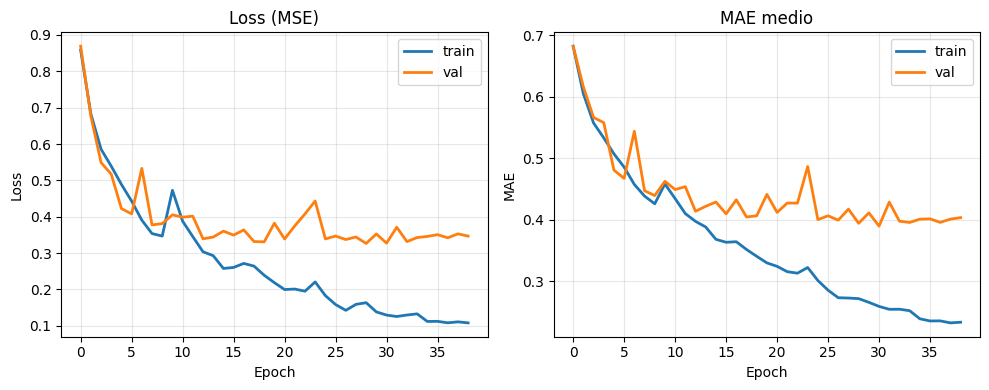

{'experiment': {'tamaño_muestra': 10000, 'tamaño_imagen': 10}, 'resultados': {'energy': {'mae': 32.11031536106297, 'rmse': 45.48397342553471, 'mape': 0.46269674651841586, 'r2': 0.9297992296135685}, 'bandgap': {'mae': 0.9175864254920791, 'rmse': 1.3382157266689654, 'mape': 1046211222664660.5, 'r2': 0.23560508337993702}, 'cohesive_energy_per_atom': {'mae': 0.5447535659116649, 'rmse': 0.7035864120766665, 'mape': 0.1549134280860689, 'r2': 0.6733047953385987}, 'corrected_cohesive_energy_per_atom': {'mae': 0.5629965396580482, 'rmse': 0.7207250116479342, 'mape': 0.15133637782734993, 'r2': 0.7084054977531171}}}


In [ ]:
experiment, results = Experiment(length_sample=1000, length_image=5, experiemnto= Deep_learning, seed=23, grafica=True)
experimento = {"experiment": experiment, "resultados": results}
print(experimento)

In [ ]:
exp_mixto = Experiment(length_sample=10000, length_image=10, experiemnto=Deep_learning, seed=23, grafica=False)
exp_mixto_embedding = Experiment(length_sample=10000, length_image=10, experiemnto=Deep_learning_2, seed=23, grafica=False)
exp_conv = Experiment(length_sample=10000, length_image=10, experiemnto=Deep_learning_conv, seed=23, grafica=False)
exp_tab = Experiment(length_sample=10000, length_image=10, experiemnto=Deep_learning_tab, seed=23, grafica=False)

comparativa = [{"experiment": exp_mixto[0], "resultados": exp_mixto[1]},
               {"experiment": exp_mixto_embedding[0], "resultados": exp_mixto_embedding[1]},
               {"experiment": exp_conv[0], "resultados": exp_conv[1]},
               {"experiment": exp_tab[0], "resultados": exp_tab[1]}]

c:\Users\Usuario\miniconda3\envs\TFG_2\lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_imagen
Received: inputs=('Tensor(shape=(32, 20, 30, 8))',)
  warnings.warn(msg)
c:\Users\Usuario\miniconda3\envs\TFG_2\lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_imagen
Received: inputs=('Tensor(shape=(None, 20, 30, 8))',)
  warnings.warn(msg)


In [17]:
parametros_exp = {"length_sample": [10000, 30000, 50000, 80000, 100000], "length_image": [5 ,10, 20, 30, 40]}
experimentos= []

for length_image in parametros_exp["length_image"]:
    try:
        for length_sample in parametros_exp["length_sample"]:
            experiment, results = Experiment(length_sample=length_sample, length_image=length_image, experiemnto=Deep_learning, seed=23, grafica=False)
            experimento = {"experiment": experiment, "resultados": results}
            experimentos.append(experimento)
    except Exception as e:
        continue
    

In [21]:
parametros_exp = {"length_sample": [10000, 30000, 50000, 80000, 100000], "length_image": [5, 10, 20, 30, 40]}
experimentos_embedding= []

for length_image in parametros_exp["length_image"]:
    try:
        for length_sample in parametros_exp["length_sample"]:
            experiment, results = Experiment(length_sample=length_sample, length_image=length_image, experiemnto=Deep_learning_2, seed=23, grafica=False)
            experimento = {"experiment": experiment, "resultados": results}
            experimentos_embedding.append(experimento)
    except Exception as e:
        continue
    

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step
500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step


In [ ]:
import pickle
with open("resultados.pkl", "wb") as f:
    pickle.dump({
        "experimentos": experimentos,
        "experimentos_embedding": experimentos_embedding,
        "comparativa": comparativa
    }, f)

In [2]:
import pickle
with open("resultados.pkl", "rb") as f:
    datos = pickle.load(f)

comparativa = datos["comparativa"]
experimentos = datos["experimentos"]
experimentos_embedding = datos["experimentos_embedding"]

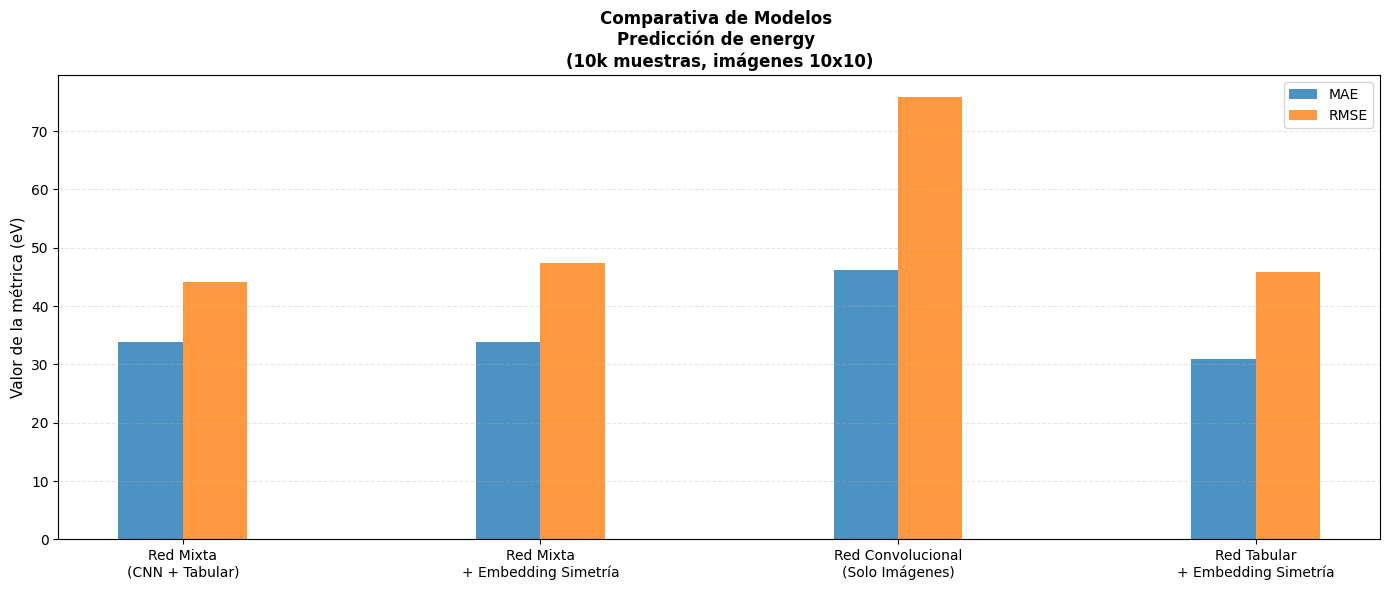

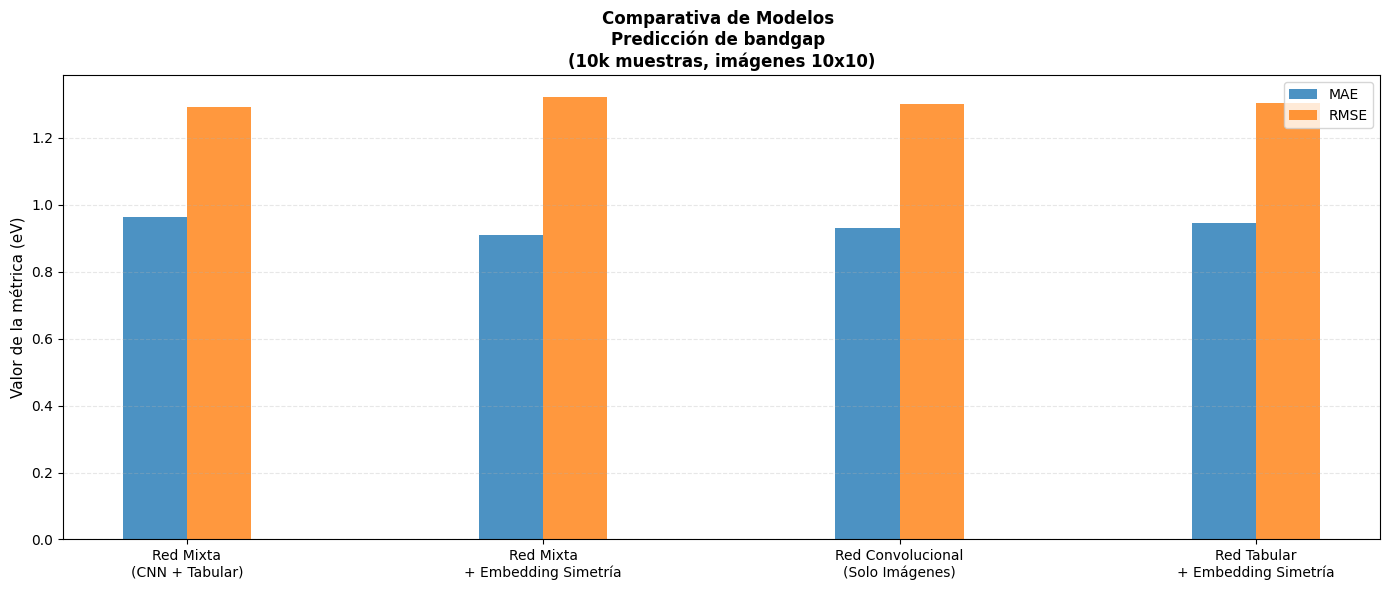

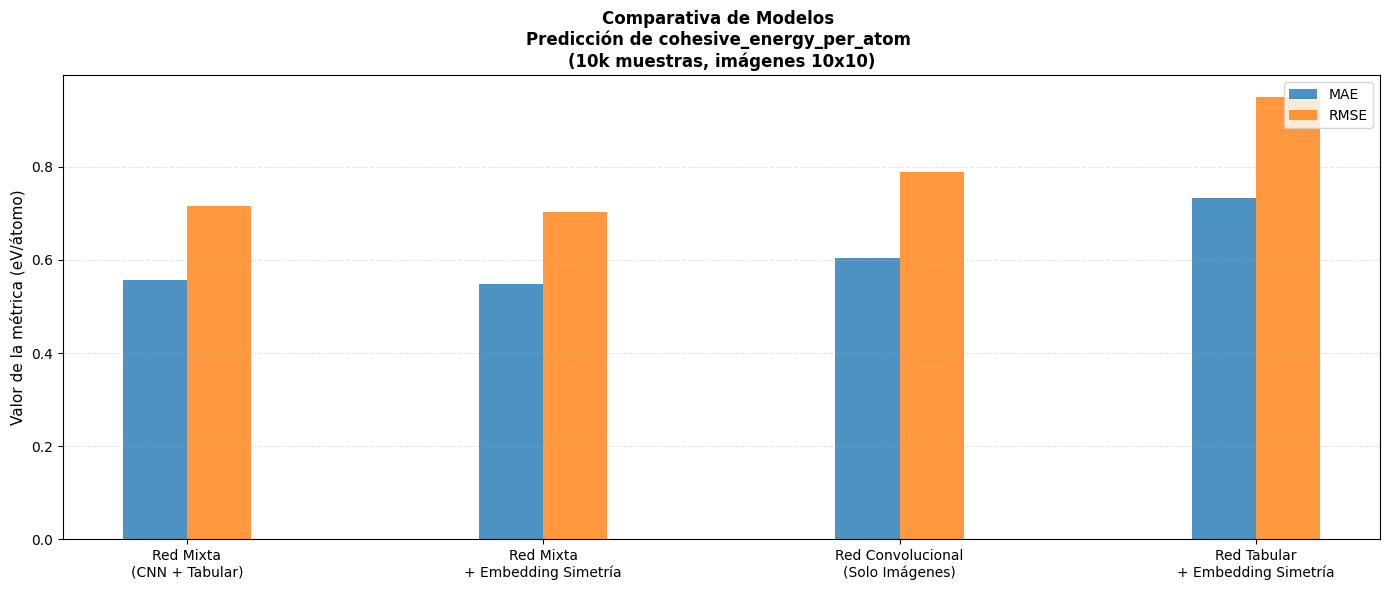

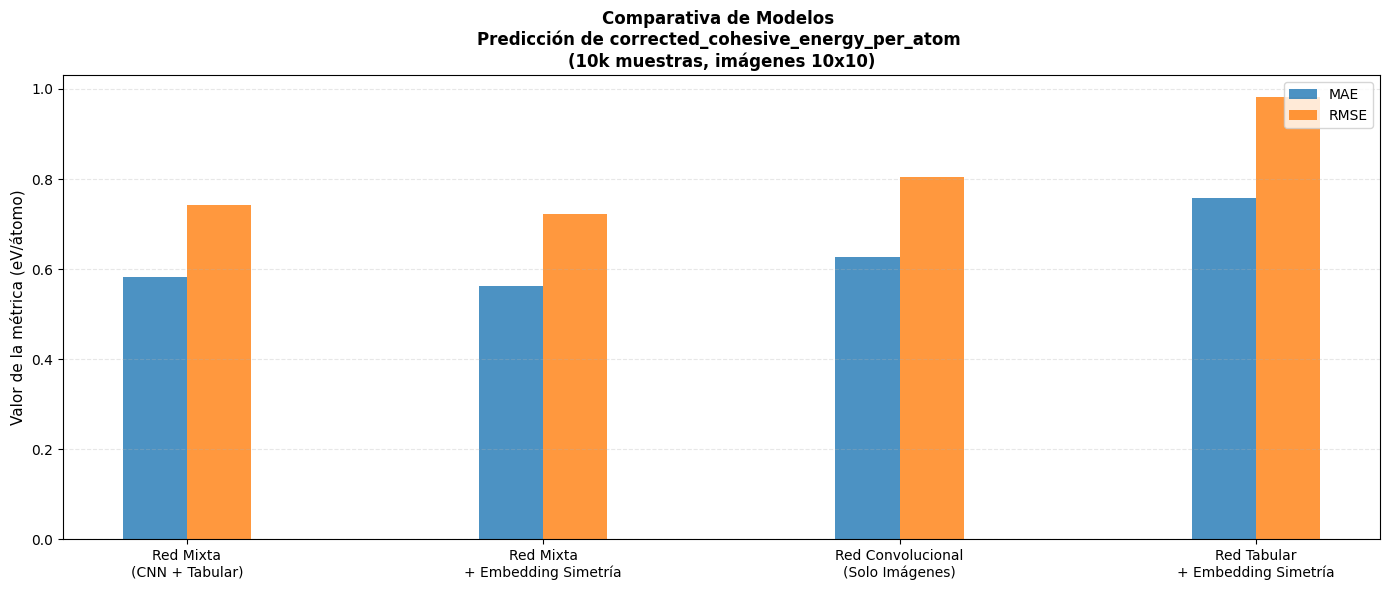

In [12]:
# ============================================================================
# VISUALIZACIÓN COMPARATIVA: Gráfico de barras de 4 métricas
# ============================================================================
# Compara el desempeño de los 4 modelos usando MAE, RMSE, MAPE y R²

target_names = [("energy", "eV"), ("bandgap", "eV"), ("cohesive_energy_per_atom", "eV/átomo"), ("corrected_cohesive_energy_per_atom", "eV/átomo")]

# Nombres de los modelos (deben coincidir con el orden de comparativa)
nombres = [
    "Red Mixta\n(CNN + Tabular)",
    "Red Mixta\n+ Embedding Simetría",
    "Red Convolucional\n(Solo Imágenes)",
    "Red Tabular\n+ Embedding Simetría"
]

for tar in target_names:


    # ========== EXTRACCIÓN DE MÉTRICAS ==========
    # Extraer valores de métricas desde los resultados
    mae = [exp["resultados"][tar[0]]["mae"] for exp in comparativa]  # Error absoluto medio
    rmse = [exp["resultados"][tar[0]]["rmse"] for exp in comparativa]  # Raíz error cuadrático medio

    # ========== CONFIGURACIÓN DE GRÁFICA, Realizado por chatGPT ========== 
    # Posiciones de barras en el eje X
    x = np.arange(len(nombres))
    width = 0.18  # Ancho de cada barra

    
    # Crear figura
    plt.figure(figsize=(14, 6))

    # ========== BARRAS PARA CADA MÉTRICA ==========
    # MAE: error absoluto medio (menor es mejor)
    plt.bar(x - width/2, mae, width, label="MAE", color="tab:blue", alpha=0.8)

    # RMSE: penaliza errores grandes (menor es mejor)
    plt.bar(x + width/2, rmse, width, label="RMSE", color="tab:orange", alpha=0.8)


    # ========== FORMATO DE LA GRÁFICA ==========
    # Etiquetas del eje X: nombres de modelos
    plt.xticks(x, nombres, fontsize=10)

    # Etiquetas de ejes
    plt.ylabel("Valor de la métrica ({})".format(tar[1]), fontsize=11)
    plt.title("Comparativa de Modelos \nPredicción de {} \n(10k muestras, imágenes 10x10)".format(tar[0]), 
            fontsize=12, fontweight="bold")

    # Leyenda y grid
    plt.legend(loc="upper right", fontsize=10)
    plt.grid(axis="y", linestyle="--", alpha=0.3)

    # Ajustar layout
    plt.tight_layout()
    plt.show()


In [ ]:
dic = {
    "modelos": ("Red Mixta (CNN + Tabular)",
               "Red Mixta + Embedding Simetría",
                "Red Convolucional (Solo Imágenes)",
                "Red Tabular + Embedding Simetría"),
    "energy": [round(res["resultados"]["energy"]["mae"], 2) for res in comparativa],
    "bandgap": [round(res["resultados"]["bandgap"]["mae"], 2) for res in comparativa],
    "cohesive_energy_per_atom": [round(res["resultados"]["cohesive_energy_per_atom"]["mae"], 2) for res in comparativa],
    "corrected_cohesive_energy_per_atom": [round(res["resultados"]["corrected_cohesive_energy_per_atom"]["mae"], 2) for res in comparativa]
}
Tabla_comparativa = pd.DataFrame(dic)
display(Tabla_comparativa)

,modelos,energy,bandgap,cohesive_energy_per_atom,corrected_cohesive_energy_per_atom
0,Red Mixta (CNN + Tabular),33.89,0.96,0.56,0.58
1,Red Mixta + Embedding Simetría,33.91,0.91,0.55,0.56
2,Red Convolucional (Solo Imágenes),46.19,0.93,0.60,0.63
3,Red Tabular + Embedding Simetría,30.87,0.95,0.73,0.76


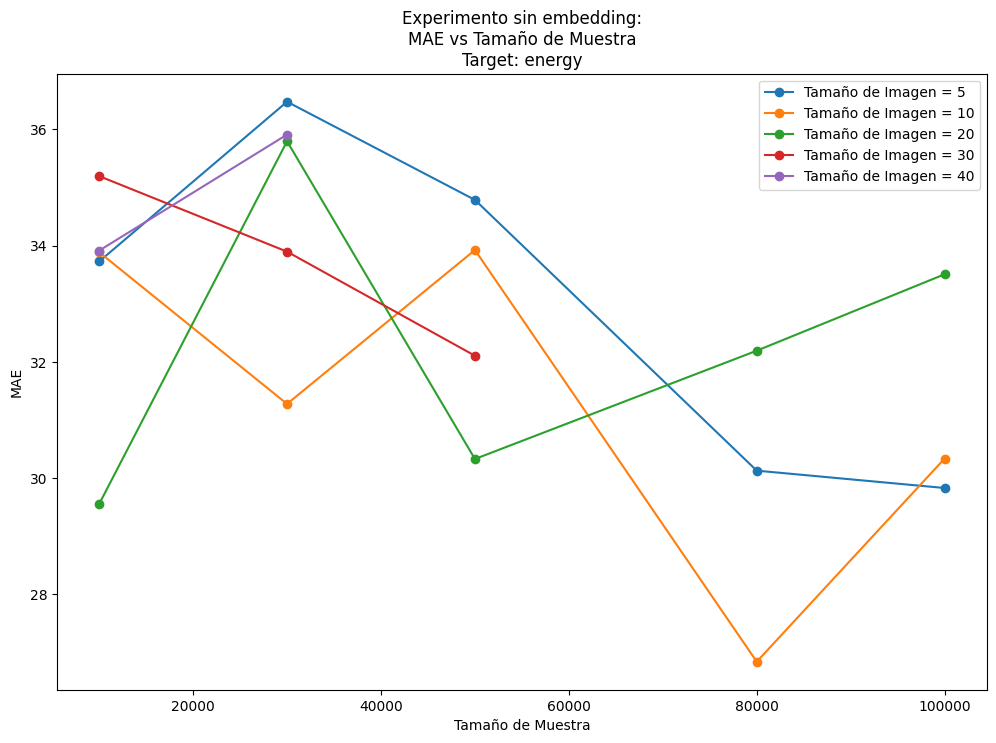

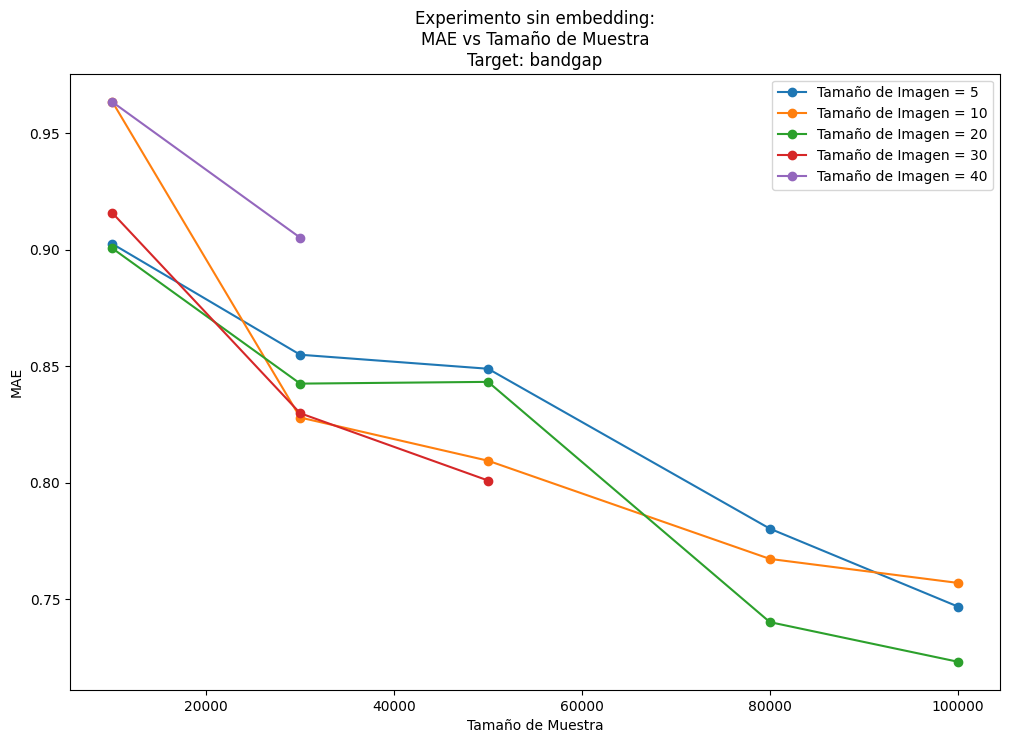

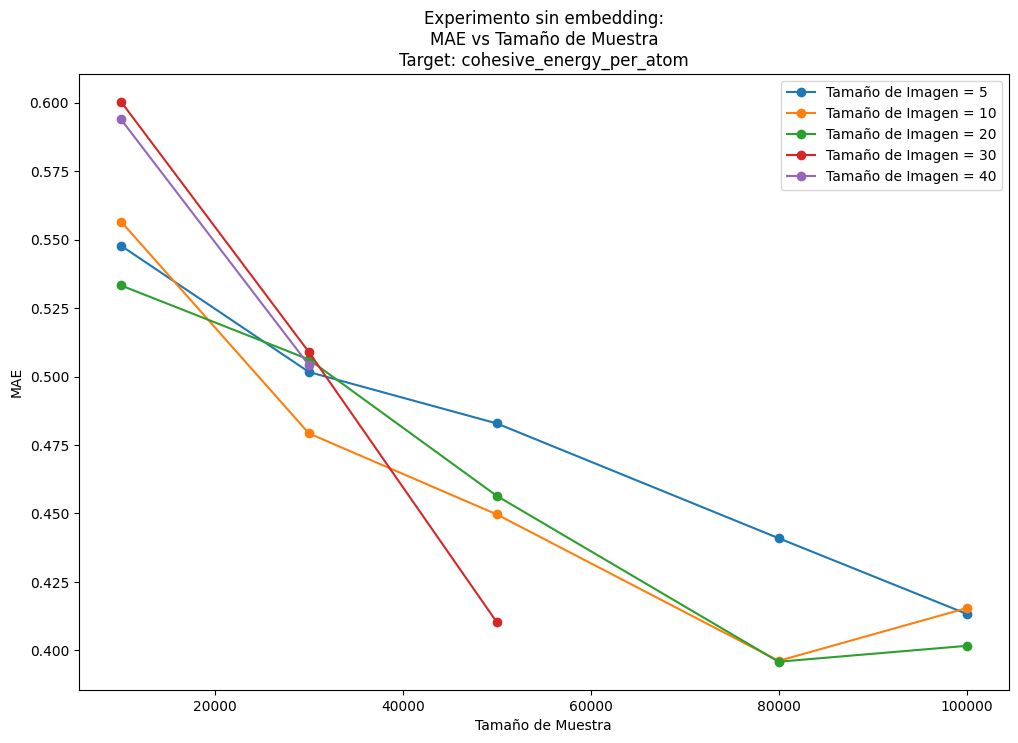

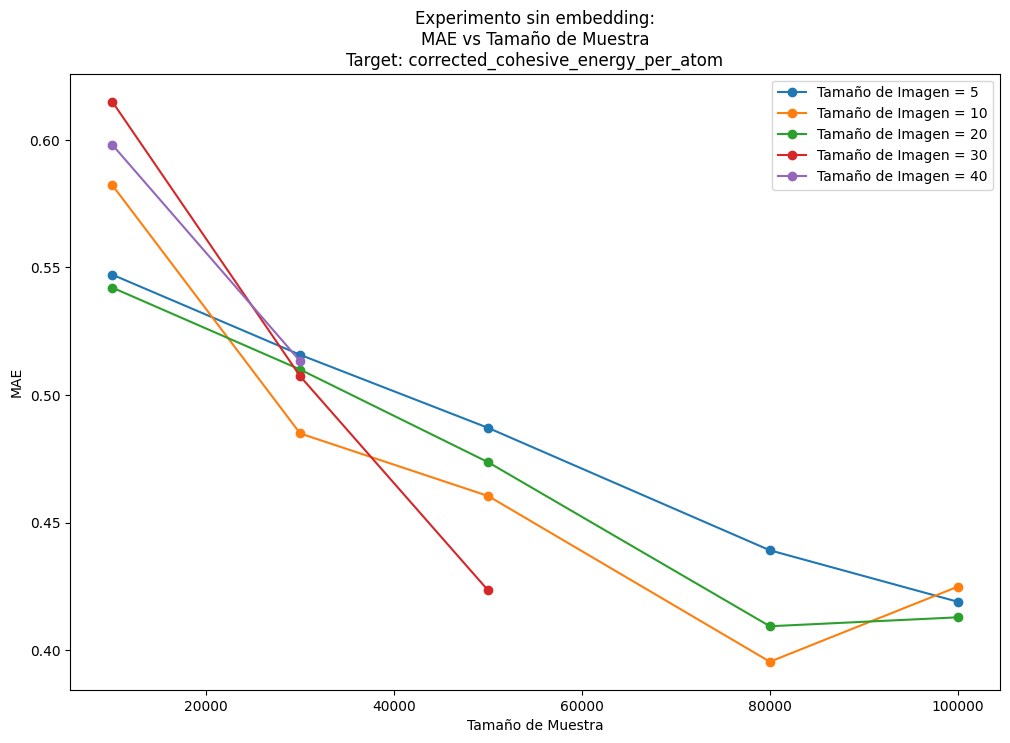

In [ ]:
target_names = ["energy","bandgap","cohesive_energy_per_atom","corrected_cohesive_energy_per_atom"]
for tar in target_names:
    plt.figure(figsize=(12, 8))
    for i in range(len(parametros_exp["length_image"])):
    
        plt.plot([exp["experiment"]["tamaño_muestra"] for exp in experimentos if exp["experiment"]["tamaño_imagen"] == parametros_exp["length_image"][i]],
                [exp["resultados"][tar]["mae"] for exp in experimentos if exp["experiment"]["tamaño_imagen"] == parametros_exp["length_image"][i]],
                label="Tamaño de Imagen = {}".format(parametros_exp["length_image"][i]),
                marker='o')
        plt.legend()
        plt.title("Experimento sin embedding:\nMAE vs Tamaño de Muestra\nTarget: {}".format(tar))
        plt.xlabel("Tamaño de Muestra")
        plt.ylabel("MAE")
    plt.show()

In [19]:
for exp in experimentos:
    print(exp)

{'experiment': {'tamaño_muestra': 10000, 'tamaño_imagen': 5}, 'resultados': {'energy': {'mae': 33.727527217929676, 'rmse': 46.58339605363823, 'mape': 0.6149699331603322, 'r2': 0.9263644767840715}, 'bandgap': {'mae': 0.9024842028568776, 'rmse': 1.262391003854526, 'mape': 1184935645569372.2, 'r2': 0.31977386585645906}, 'cohesive_energy_per_atom': {'mae': 0.5477305651439327, 'rmse': 0.712231617457833, 'mape': 0.15855249848094288, 'r2': 0.6652270412796846}, 'corrected_cohesive_energy_per_atom': {'mae': 0.5471924870181568, 'rmse': 0.7184284222604062, 'mape': 0.15044538532445778, 'r2': 0.7102608680335024}}}
{'experiment': {'tamaño_muestra': 30000, 'tamaño_imagen': 5}, 'resultados': {'energy': {'mae': 36.47661157839973, 'rmse': 55.3484606395648, 'mape': 0.5499730006568578, 'r2': 0.9083506716833003}, 'bandgap': {'mae': 0.8548904107161482, 'rmse': 1.2192409157561495, 'mape': 1023048906574666.4, 'r2': 0.35642330685371004}, 'cohesive_energy_per_atom': {'mae': 0.501637853995612, 'rmse': 0.66434654

In [22]:
for exp in experimentos_embedding:
    print(exp)

{'experiment': {'tamaño_muestra': 10000, 'tamaño_imagen': 5}, 'resultados': {'energy': {'mae': 29.74286089981344, 'rmse': 39.87108544616912, 'mape': 0.5029371924867005, 'r2': 0.9460562415599597}, 'bandgap': {'mae': 0.8820963328722421, 'rmse': 1.256637113065048, 'mape': 1143165747204210.0, 'r2': 0.325960581583405}, 'cohesive_energy_per_atom': {'mae': 0.5416661836176234, 'rmse': 0.701990369620832, 'mape': 0.15440326446175134, 'r2': 0.6747852901403624}, 'corrected_cohesive_energy_per_atom': {'mae': 0.5427197459481534, 'rmse': 0.7139317634149777, 'mape': 0.14758423050511105, 'r2': 0.7138764842375823}}}
{'experiment': {'tamaño_muestra': 30000, 'tamaño_imagen': 5}, 'resultados': {'energy': {'mae': 30.65181519584093, 'rmse': 46.422683990640195, 'mape': 0.45540832294209205, 'r2': 0.935526880275985}, 'bandgap': {'mae': 0.8326187871555129, 'rmse': 1.1997044703108448, 'mape': 1005046793325681.5, 'r2': 0.37688270543197433}, 'cohesive_energy_per_atom': {'mae': 0.47964067399301297, 'rmse': 0.6442343

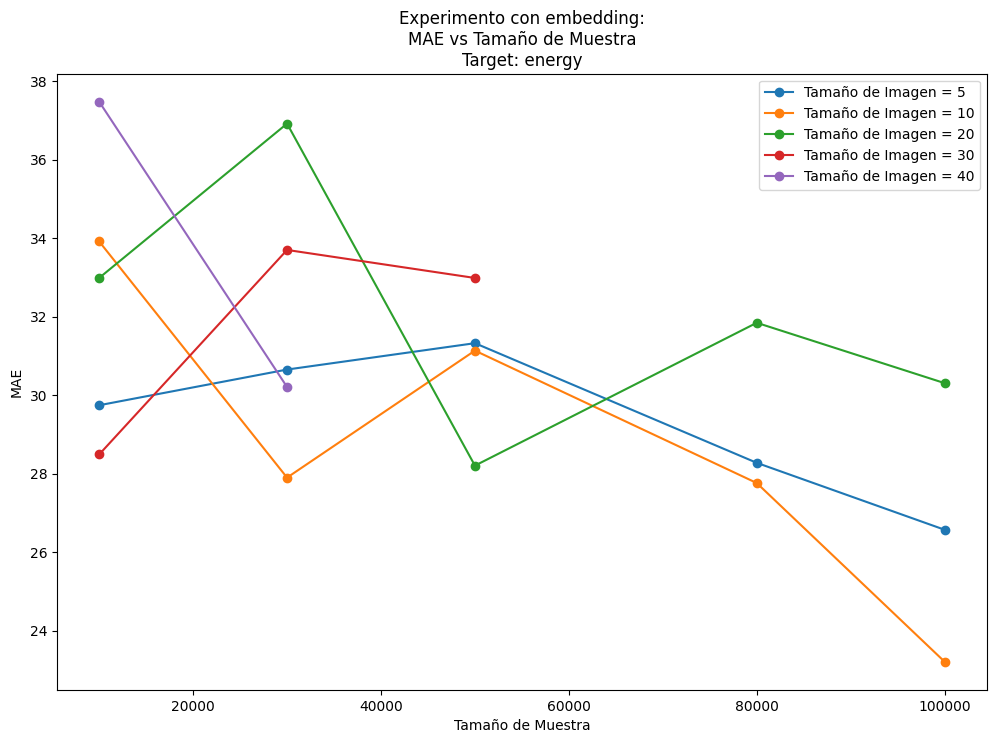

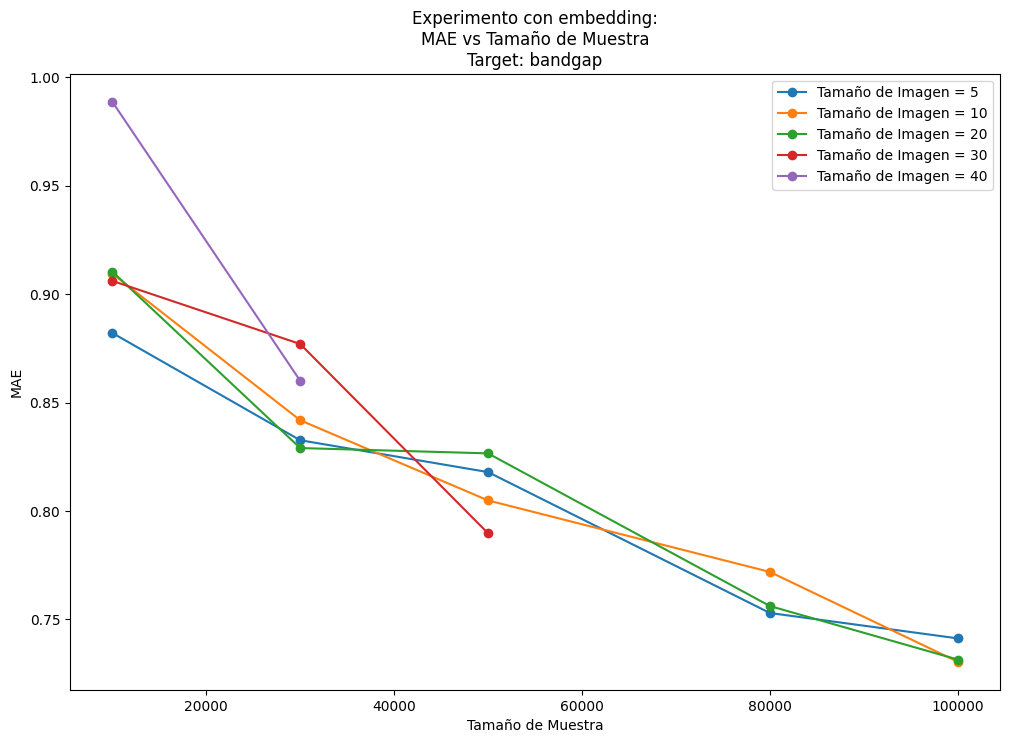

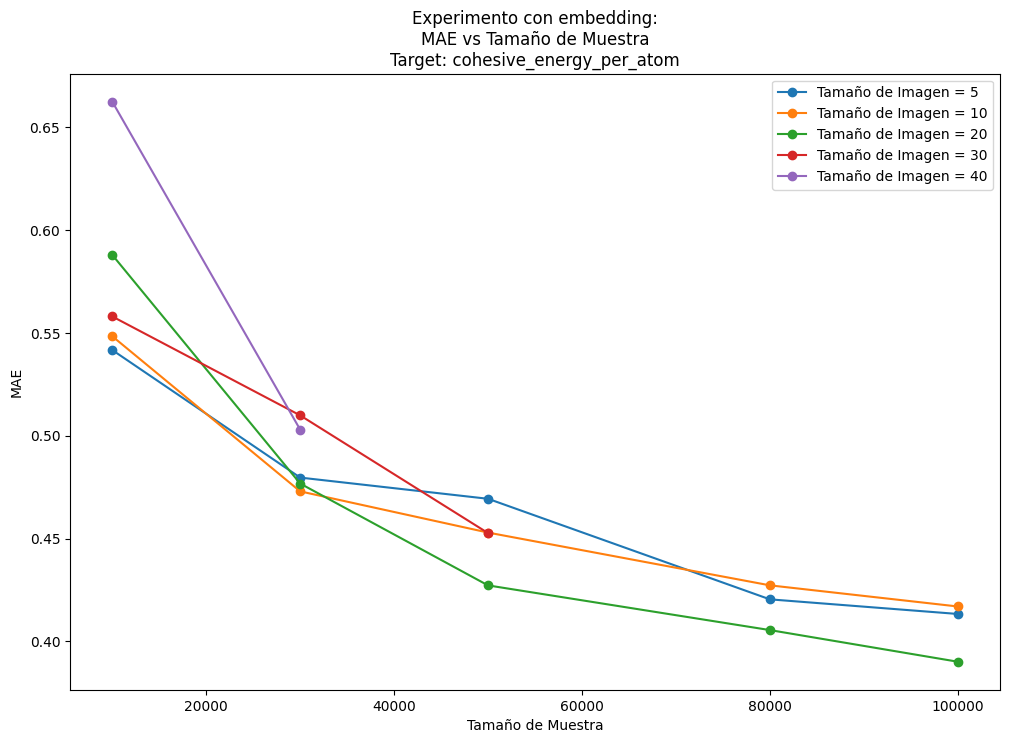

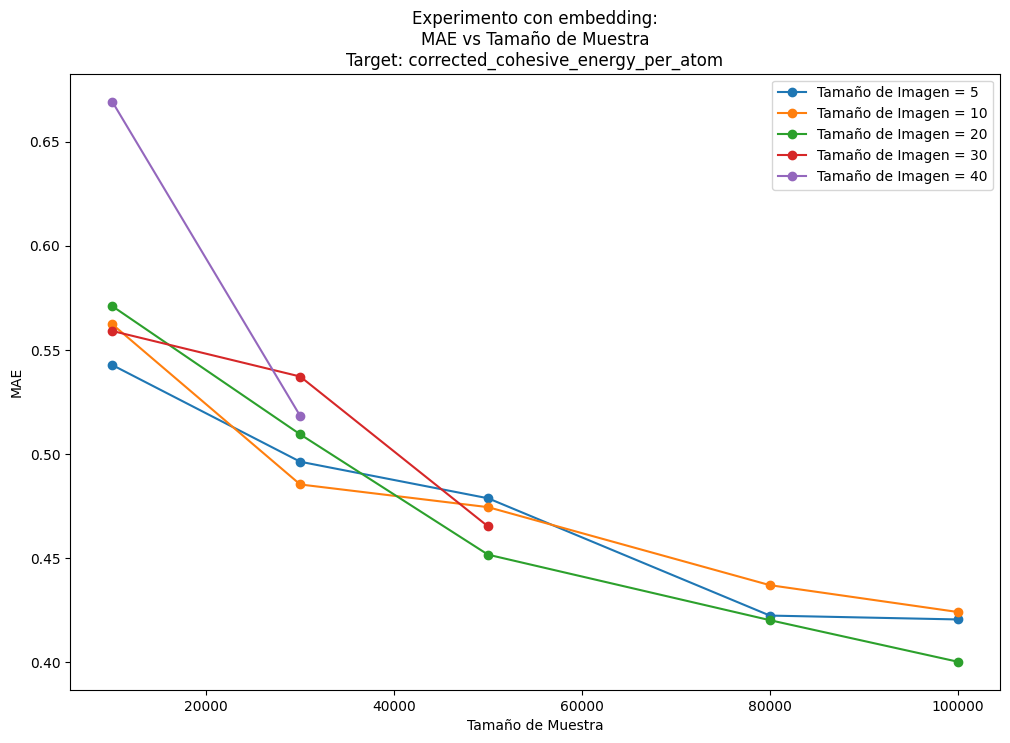

In [ ]:
for tar in target_names:
    plt.figure(figsize=(12, 8))
    for i in range(len(parametros_exp["length_image"])):
    
        plt.plot([exp["experiment"]["tamaño_muestra"] for exp in experimentos_embedding if exp["experiment"]["tamaño_imagen"] == parametros_exp["length_image"][i]],
                [exp["resultados"][tar]["mae"] for exp in experimentos_embedding if exp["experiment"]["tamaño_imagen"] == parametros_exp["length_image"][i]],
                label = "Tamaño de Imagen = {}".format(parametros_exp["length_image"][i]),
                marker='o')
        plt.legend()
        plt.title("Experimento con embedding:\nMAE vs Tamaño de Muestra\nTarget: {}".format(tar))
        plt.xlabel("Tamaño de Muestra")
        plt.ylabel("MAE")
    plt.show()

In [12]:
experimentos

[{'experiment': {'tamaño_muestra': 10000, 'tamaño_imagen': 5},
  'resultados': {'energy': {'mae': 33.727527217929676,
    'rmse': 46.58339605363823,
    'mape': 0.6149699331603322,
    'r2': 0.9263644767840715},
   'bandgap': {'mae': 0.9024842028568776,
    'rmse': 1.262391003854526,
    'mape': 1184935645569372.2,
    'r2': 0.31977386585645906},
   'cohesive_energy_per_atom': {'mae': 0.5477305651439327,
    'rmse': 0.712231617457833,
    'mape': 0.15855249848094288,
    'r2': 0.6652270412796846},
   'corrected_cohesive_energy_per_atom': {'mae': 0.5471924870181568,
    'rmse': 0.7184284222604062,
    'mape': 0.15044538532445778,
    'r2': 0.7102608680335024}}},
 {'experiment': {'tamaño_muestra': 30000, 'tamaño_imagen': 5},
  'resultados': {'energy': {'mae': 36.47661157839973,
    'rmse': 55.3484606395648,
    'mape': 0.5499730006568578,
    'r2': 0.9083506716833003},
   'bandgap': {'mae': 0.8548904107161482,
    'rmse': 1.2192409157561495,
    'mape': 1023048906574666.4,
    'r2': 0.35

In [5]:
Tablas_sin_embedding = []

In [ ]:
dic = {
    "Resolucion" : ("5x5", "10x10", "20x20", "30x30", "40x40"),
    "10000 muestras": [round(exp["resultados"]["energy"]["mae"], 2) for exp in experimentos if exp["experiment"]["tamaño_muestra"] == 10000],
    "30000 muestras": [round(exp["resultados"]["energy"]["mae"], 2) for exp in experimentos if exp["experiment"]["tamaño_muestra"] == 30000],
    "50000 muestras": [round(exp["resultados"]["energy"]["mae"], 2) for exp in experimentos if exp["experiment"]["tamaño_muestra"] == 50000],
    "80000 muestras": [round(exp["resultados"]["energy"]["mae"], 2) for exp in experimentos if exp["experiment"]["tamaño_muestra"] == 80000],
    "100000 muestras": [round(exp["resultados"]["energy"]["mae"], 2) for exp in experimentos if exp["experiment"]["tamaño_muestra"] == 100000]
}
medias = []
for key in dic:
    if len(dic[key]) < 5:
        dic[key] = dic[key] + [None] * (5 - len(dic[key]))

Tablas_sin_embedding.append(pd.DataFrame(dic))
display(Tablas_sin_embedding[0])

,Resolucion,10000 muestras,30000 muestras,50000 muestras,80000 muestras,100000 muestras
0,5x5,33.73,36.48,34.79,30.13,29.83
1,10x10,33.89,31.28,33.92,26.84,30.34
2,20x20,29.55,35.80,30.33,32.19,33.51
3,30x30,35.20,33.90,32.11,NaN,NaN
4,40x40,33.91,35.91,NaN,NaN,NaN


In [ ]:
dic = {
    "Resolucion" : ("5x5", "10x10", "20x20", "30x30", "40x40"),
    "10000 muestras": [round(exp["resultados"]["bandgap"]["mae"], 2) for exp in experimentos if exp["experiment"]["tamaño_muestra"] == 10000],
    "30000 muestras": [round(exp["resultados"]["bandgap"]["mae"], 2) for exp in experimentos if exp["experiment"]["tamaño_muestra"] == 30000],
    "50000 muestras": [round(exp["resultados"]["bandgap"]["mae"], 2) for exp in experimentos if exp["experiment"]["tamaño_muestra"] == 50000],
    "80000 muestras": [round(exp["resultados"]["bandgap"]["mae"], 2) for exp in experimentos if exp["experiment"]["tamaño_muestra"] == 80000],
    "100000 muestras": [round(exp["resultados"]["bandgap"]["mae"], 2) for exp in experimentos if exp["experiment"]["tamaño_muestra"] == 100000]
}
medias = []
for key in dic:
    if len(dic[key]) < 5:
        dic[key] = dic[key] + [None] * (5 - len(dic[key]))

Tablas_sin_embedding.append(pd.DataFrame(dic))
display(Tablas_sin_embedding[1])

,Resolucion,10000 muestras,30000 muestras,50000 muestras,80000 muestras,100000 muestras
0,5x5,0.90,0.85,0.85,0.78,0.75
1,10x10,0.96,0.83,0.81,0.77,0.76
2,20x20,0.90,0.84,0.84,0.74,0.72
3,30x30,0.92,0.83,0.80,NaN,NaN
4,40x40,0.96,0.91,NaN,NaN,NaN


In [ ]:
dic = {
    "Resolucion" : ("5x5", "10x10", "20x20", "30x30", "40x40"),
    "10000 muestras": [round(exp["resultados"]["cohesive_energy_per_atom"]["mae"], 2) for exp in experimentos if exp["experiment"]["tamaño_muestra"] == 10000],
    "30000 muestras": [round(exp["resultados"]["cohesive_energy_per_atom"]["mae"], 2) for exp in experimentos if exp["experiment"]["tamaño_muestra"] == 30000],
    "50000 muestras": [round(exp["resultados"]["cohesive_energy_per_atom"]["mae"], 2) for exp in experimentos if exp["experiment"]["tamaño_muestra"] == 50000],
    "80000 muestras": [round(exp["resultados"]["cohesive_energy_per_atom"]["mae"], 2) for exp in experimentos if exp["experiment"]["tamaño_muestra"] == 80000],
    "100000 muestras": [round(exp["resultados"]["cohesive_energy_per_atom"]["mae"], 2) for exp in experimentos if exp["experiment"]["tamaño_muestra"] == 100000]
}
medias = []
for key in dic:
    if len(dic[key]) < 5:
        dic[key] = dic[key] + [None] * (5 - len(dic[key]))


Tablas_sin_embedding.append(pd.DataFrame(dic))
display(Tablas_sin_embedding[2])

,Resolucion,10000 muestras,30000 muestras,50000 muestras,80000 muestras,100000 muestras
0,5x5,0.55,0.50,0.48,0.44,0.41
1,10x10,0.56,0.48,0.45,0.40,0.42
2,20x20,0.53,0.51,0.46,0.40,0.40
3,30x30,0.60,0.51,0.41,NaN,NaN
4,40x40,0.59,0.50,NaN,NaN,NaN


In [ ]:
dic = {
    "Resolucion" : ("5x5", "10x10", "20x20", "30x30", "40x40"),
    "10000 muestras": [round(exp["resultados"]["corrected_cohesive_energy_per_atom"]["mae"], 2) for exp in experimentos if exp["experiment"]["tamaño_muestra"] == 10000],
    "30000 muestras": [round(exp["resultados"]["corrected_cohesive_energy_per_atom"]["mae"], 2) for exp in experimentos if exp["experiment"]["tamaño_muestra"] == 30000],
    "50000 muestras": [round(exp["resultados"]["corrected_cohesive_energy_per_atom"]["mae"], 2) for exp in experimentos if exp["experiment"]["tamaño_muestra"] == 50000],
    "80000 muestras": [round(exp["resultados"]["corrected_cohesive_energy_per_atom"]["mae"], 2) for exp in experimentos if exp["experiment"]["tamaño_muestra"] == 80000],
    "100000 muestras": [round(exp["resultados"]["corrected_cohesive_energy_per_atom"]["mae"], 2) for exp in experimentos if exp["experiment"]["tamaño_muestra"] == 100000]
}
medias = []
for key in dic:
    if len(dic[key]) < 5:
        dic[key] = dic[key] + [None] * (5 - len(dic[key]))

Tablas_sin_embedding.append(pd.DataFrame(dic))
display(Tablas_sin_embedding[3])

,Resolucion,10000 muestras,30000 muestras,50000 muestras,80000 muestras,100000 muestras
0,5x5,0.55,0.52,0.49,0.44,0.42
1,10x10,0.58,0.48,0.46,0.40,0.42
2,20x20,0.54,0.51,0.47,0.41,0.41
3,30x30,0.61,0.51,0.42,NaN,NaN
4,40x40,0.60,0.51,NaN,NaN,NaN


In [13]:
Tablas_con_embedding = []
for tar in target_names:
    dic = {
    "Resolucion" : ("5x5", "10x10", "20x20", "30x30", "40x40"),
    "10000 muestras": [round(exp["resultados"][tar[0]]["mae"], 2) for exp in experimentos_embedding if exp["experiment"]["tamaño_muestra"] == 10000],
    "30000 muestras": [round(exp["resultados"][tar[0]]["mae"], 2) for exp in experimentos_embedding if exp["experiment"]["tamaño_muestra"] == 30000],
    "50000 muestras": [round(exp["resultados"][tar[0]]["mae"], 2) for exp in experimentos_embedding if exp["experiment"]["tamaño_muestra"] == 50000],
    "80000 muestras": [round(exp["resultados"][tar[0]]["mae"], 2) for exp in experimentos_embedding if exp["experiment"]["tamaño_muestra"] == 80000],
    "100000 muestras": [round(exp["resultados"][tar[0]]["mae"], 2) for exp in experimentos_embedding if exp["experiment"]["tamaño_muestra"] == 100000]
    }
    medias = []
    for key in dic:
        if len(dic[key]) < 5:
            dic[key] = dic[key] + [None] * (5 - len(dic[key]))

    Tablas_con_embedding.append(pd.DataFrame(dic))

In [14]:
Tablas_comp_embedding = []
for i in range(4):
    resultado = Tablas_sin_embedding[i].copy()
    resultado.iloc[:, 1:] = round(Tablas_sin_embedding[i].iloc[:, 1:] - Tablas_con_embedding[i].iloc[:, 1:], 2)
    Tablas_comp_embedding.append(resultado)
    display(Tablas_comp_embedding[i])

,Resolucion,10000 muestras,30000 muestras,50000 muestras,80000 muestras,100000 muestras
0,5x5,3.99,5.83,3.47,1.85,3.26
1,10x10,-0.02,3.38,2.79,-0.92,7.13
2,20x20,-3.43,-1.11,2.13,0.35,3.20
3,30x30,6.71,0.20,-0.87,NaN,NaN
4,40x40,-3.56,5.70,NaN,NaN,NaN


,Resolucion,10000 muestras,30000 muestras,50000 muestras,80000 muestras,100000 muestras
0,5x5,0.02,0.02,0.03,0.03,0.01
1,10x10,0.05,-0.01,0.01,0.00,0.03
2,20x20,-0.01,0.01,0.01,-0.02,-0.01
3,30x30,0.01,-0.05,0.01,NaN,NaN
4,40x40,-0.03,0.05,NaN,NaN,NaN


,Resolucion,10000 muestras,30000 muestras,50000 muestras,80000 muestras,100000 muestras
0,5x5,0.01,0.02,0.01,0.02,0.00
1,10x10,0.01,0.01,0.00,-0.03,0.00
2,20x20,-0.06,0.03,0.03,-0.01,0.01
3,30x30,0.04,0.00,-0.04,NaN,NaN
4,40x40,-0.07,0.00,NaN,NaN,NaN


,Resolucion,10000 muestras,30000 muestras,50000 muestras,80000 muestras,100000 muestras
0,5x5,0.01,0.02,0.01,0.02,0.00
1,10x10,0.02,-0.01,-0.01,-0.04,0.00
2,20x20,-0.03,0.00,0.02,-0.01,0.01
3,30x30,0.05,-0.03,-0.05,NaN,NaN
4,40x40,-0.07,-0.01,NaN,NaN,NaN
